# Lab 1: Multi-Class Feed-Forward Neural Network Using PyTorch

## Part B: Model Implementation

This notebook implements a multi-class text classification model using a feed-forward neural network in PyTorch. The AG News Topic Classification Dataset is represented using bag-of-words features and classified into four news categories.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import nltk
import torch

from tqdm import tqdm

In [2]:
tqdm.pandas()

### Enable tqdm Progress Bars in pandas

The `tqdm` library provides progress bars for long-running operations. The `tqdm.pandas()` command integrates tqdm with pandas so that functions such as `progress_apply()` can display progress while processing DataFrame rows.

In [3]:
# Enable tqdm progress bars for pandas operations

tqdm.pandas()

### Download the AG News Dataset

The AG News dataset is provided as three files: `train.csv`, `test.csv`, and `classes.txt`.  
The following code creates the required data directory and downloads the files if they are not already available locally.

In [4]:
# Download the AG News dataset

from pathlib import Path
from urllib.request import urlretrieve

# Create the dataset directory
data_dir = Path("data/ag_news_csv")
data_dir.mkdir(parents=True, exist_ok=True)

# URLs for the AG News dataset files
base_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv"

files = ["train.csv", "test.csv", "classes.txt"]

# Download each file only if it does not already exist
for filename in files:
    file_path = data_dir / filename

    if not file_path.exists():
        print(f"Downloading {filename}...")
        urlretrieve(f"{base_url}/{filename}", file_path)
    else:
        print(f"{filename} already exists.")

print("\nDataset setup complete.")


Dataset setup complete.


### Load and Examine the Training Dataset

The AG News training dataset is stored in `train.csv`. The file does not contain a header row, so column names are assigned manually as `class`, `title`, and `description`. After loading the data, we examine its structure, dimensions, and sample records before performing any preprocessing.

In [5]:
# Load the AG News training dataset

train_path = data_dir / "train.csv"

train_df = pd.read_csv(
    train_path,
    header=None,
    names=["class", "title", "description"]
)

print("Training dataset shape:", train_df.shape)

train_df.head()

Training dataset shape: (120000, 3)


,class,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


### Examine the Dataset Structure

Before preprocessing, the dataset is examined to understand its column types, identify missing values, and determine the distribution of the target classes.

In [6]:
# Examine the structure of the training dataset

print("Dataset information:")
train_df.info()

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nClass distribution:")
print(train_df["class"].value_counts().sort_index())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   class        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

Missing values:
class          0
title          0
description    0
dtype: int64

Class distribution:
class
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


### Dataset Description

The AG News training dataset contains 120,000 news articles and three columns: `class`, `title`, and `description`. The `class` column represents the target news category, while the `title` and `description` columns contain the textual information used for classification.

There are no missing values in any of the three columns. The dataset contains four classes labeled 1 through 4, with 30,000 training examples in each class. Therefore, the training dataset is evenly balanced across the four news categories. This balanced distribution is useful because the model receives the same number of training examples from each category and is less likely to become biased toward a majority class.

### Clean Backslash Characters

Some article titles and descriptions contain backslash characters within the text. These characters are replaced with spaces before tokenization so that words separated by a backslash are treated as separate tokens.

In [7]:
# Replace backslashes with spaces in the text columns

train_df[["title", "description"]] = train_df[["title", "description"]].replace(
    r"\\",
    " ",
    regex=True
)

train_df.head()

,class,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [8]:
# Verify whether any backslashes remain in the text columns

title_backslashes = train_df["title"].str.contains(r"\\", regex=True).sum()
description_backslashes = train_df["description"].str.contains(r"\\", regex=True).sum()

print("Titles containing backslashes:", title_backslashes)
print("Descriptions containing backslashes:", description_backslashes)

Titles containing backslashes: 0
Descriptions containing backslashes: 0


### Prepare NLTK for Tokenization

NLTK's `word_tokenize()` function is used to split text into individual tokens such as words and punctuation marks. Before using the tokenizer, the required NLTK tokenization resources are downloaded.

In [9]:
# Download the NLTK resources required by word_tokenize()

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dubey\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dubey\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

### Tokenize the News Articles

The title and description of each news article are combined and tokenized using NLTK's `word_tokenize()` function. Tokenization breaks the text into individual words and punctuation symbols. The resulting list of tokens is stored in a new `tokens` column.

The `progress_apply()` method is used instead of the standard pandas `apply()` method so that tqdm displays the progress of tokenizing all 120,000 training records.

In [10]:
# Tokenize the title and description using NLTK

from nltk.tokenize import word_tokenize

train_df["tokens"] = train_df.progress_apply(
    lambda row: word_tokenize(row["title"] + " " + row["description"]),
    axis=1
)

train_df[["class", "title", "description", "tokens"]].head()

100%|██████████| 120000/120000 [00:27<00:00, 4432.35it/s]


,class,title,description,tokens
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...","[Wall, St., Bears, Claw, Back, Into, the, Blac..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,"[Carlyle, Looks, Toward, Commercial, Aerospace..."
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries ab...,"[Oil, and, Economy, Cloud, Stocks, ', Outlook,..."
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export f...,"[Iraq, Halts, Oil, Exports, from, Main, Southe..."
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","[Oil, prices, soar, to, all-time, record, ,, p..."


### Normalize and Tokenize the Text

The title and description are combined into a single text field and converted to lowercase before tokenization. Lowercasing reduces unnecessary duplication in the vocabulary because words such as `Oil` and `oil` are treated as the same term.

The cleaned text is then tokenized using NLTK's `word_tokenize()` function.

In [11]:
# Combine title and description and convert the text to lowercase

train_df["text"] = (
    train_df["title"].str.lower()
    + " "
    + train_df["description"].str.lower()
)

# Tokenize the normalized text
train_df["tokens"] = train_df["text"].progress_map(word_tokenize)

train_df[["class", "text", "tokens"]].head()

100%|██████████| 120000/120000 [00:24<00:00, 4938.85it/s]


,class,text,tokens
0,3,wall st. bears claw back into the black (reute...,"[wall, st., bears, claw, back, into, the, blac..."
1,3,carlyle looks toward commercial aerospace (reu...,"[carlyle, looks, toward, commercial, aerospace..."
2,3,oil and economy cloud stocks' outlook (reuters...,"[oil, and, economy, cloud, stocks, ', outlook,..."
3,3,iraq halts oil exports from main southern pipe...,"[iraq, halts, oil, exports, from, main, southe..."
4,3,"oil prices soar to all-time record, posing new...","[oil, prices, soar, to, all-time, record, ,, p..."


### Load the AG News Class Labels

The `classes.txt` file contains the names of the four news categories represented by the numeric class labels in the dataset. Loading these labels makes the model outputs easier to interpret during evaluation.

In [12]:
# Load the class names

classes_path = data_dir / "classes.txt"

with open(classes_path, "r", encoding="utf-8") as file:
    class_names = [line.strip() for line in file]

print("Class names:")
for i, class_name in enumerate(class_names, start=1):
    print(f"{i}: {class_name}")

Class names:
1: World
2: Sports
3: Business
4: Sci/Tech


### Split the Training Data into Training and Validation Sets

The original AG News training dataset is divided into training and validation sets. The training portion is used to create the vocabulary and train the neural network, while the validation portion can be used to evaluate the model during development.

A stratified 80/20 split is used so that each of the four news classes remains evenly represented in both datasets.

In [13]:
# Split the original training data into training and validation sets

from sklearn.model_selection import train_test_split

train_data, dev_data = train_test_split(
    train_df,
    train_size=0.80,
    random_state=1234,
    stratify=train_df["class"]
)

# Reset the row indexes after splitting
train_data = train_data.reset_index(drop=True)
dev_data = dev_data.reset_index(drop=True)

print(f"Training rows: {len(train_data):,}")
print(f"Validation rows: {len(dev_data):,}")

print("\nTraining class distribution:")
print(train_data["class"].value_counts().sort_index())

print("\nValidation class distribution:")
print(dev_data["class"].value_counts().sort_index())

Training rows: 96,000
Validation rows: 24,000

Training class distribution:
class
1    24000
2    24000
3    24000
4    24000
Name: count, dtype: int64

Validation class distribution:
class
1    6000
2    6000
3    6000
4    6000
Name: count, dtype: int64


### Create the Vocabulary from the Training Data

A vocabulary is created using only the training portion of the dataset. All tokens are counted, and only tokens that occur more than 10 times are retained. Removing very rare words reduces the vocabulary size and the dimensionality of the bag-of-words representation.

A special `[UNK]` (unknown) token is added at index 0. Words that are not present in the vocabulary can later be mapped to this token.

In [14]:
# Create the vocabulary from the training data

threshold = 10

# Count how often every token occurs in the training data
token_counts = train_data["tokens"].explode().value_counts()

# Keep only tokens occurring more than the threshold
frequent_tokens = token_counts[token_counts > threshold]

# Create mappings between tokens and integer IDs
id_to_token = ["[UNK]"] + frequent_tokens.index.tolist()
token_to_id = {token: i for i, token in enumerate(id_to_token)}

# Vocabulary size
vocabulary_size = len(id_to_token)

print(f"Vocabulary size: {vocabulary_size:,}")

Vocabulary size: 17,438


### Inspect the Vocabulary

The vocabulary maps each retained token to a unique integer ID. Index 0 is reserved for the `[UNK]` token, while the remaining indices correspond to tokens that occurred more than 10 times in the training data.

In [15]:
# Inspect the first few vocabulary entries

print("First 20 vocabulary entries:\n")

for i in range(20):
    print(f"{i}: {id_to_token[i]}")

First 20 vocabulary entries:

0: [UNK]
1: the
2: ,
3: .
4: to
5: a
6: of
7: in
8: ;
9: and
10: on
11: for
12: #
13: 39
14: (
15: )
16: -
17: s
18: that
19: with


In [16]:
# Examine token-to-ID mappings for selected words

sample_words = ["the", "news", "business", "sports", "oil"]

for word in sample_words:
    print(f"{word:10s} -> {token_to_id.get(word, 0)}")

the        -> 1
news       -> 144
business   -> 139
sports     -> 260
oil        -> 67


### Create Bag-of-Words Feature Vectors

Each tokenized article is converted into a bag-of-words feature representation. For every token, its vocabulary ID is identified and the number of times it occurs in the article is counted.

The representation is stored as a dictionary containing only the vocabulary IDs that occur in the article. Tokens that are not present in the retained vocabulary are mapped to the `[UNK]` token at index 0.

In [17]:
# Create bag-of-words feature representations

from collections import defaultdict

def make_feature_vector(tokens, unk_id=0):
    vector = defaultdict(int)

    for token in tokens:
        token_id = token_to_id.get(token, unk_id)
        vector[token_id] += 1

    return dict(vector)


train_data["features"] = train_data["tokens"].progress_map(make_feature_vector)
dev_data["features"] = dev_data["tokens"].progress_map(make_feature_vector)

print("Bag-of-words features created.")

100%|██████████| 24000/24000 [00:00<00:00, 50905.22it/s]

Bag-of-words features created.


### Inspect a Bag-of-Words Representation

To verify the feature engineering process, one training example is examined from its original text through tokenization and bag-of-words conversion. The feature dictionary stores vocabulary IDs as keys and token frequencies as values.

In [18]:
# Inspect one training example

example_index = 0

example = train_data.iloc[example_index]

print("Class:", example["class"])
print("Class name:", class_names[example["class"] - 1])

print("\nText:")
print(example["text"])

print("\nFirst 20 tokens:")
print(example["tokens"][:20])

print("\nFirst 20 bag-of-words features:")
print(list(example["features"].items())[:20])

Class: 4
Class name: Sci/Tech

Text:
china shuts 1,600 cybercafes a furious china has shut down over 1,600 internet cafes and arrested people in a bid to curb the menace of content which is harmful to public morality.

First 20 tokens:
['china', 'shuts', '1,600', 'cybercafes', 'a', 'furious', 'china', 'has', 'shut', 'down', 'over', '1,600', 'internet', 'cafes', 'and', 'arrested', 'people', 'in', 'a', 'bid']

First 20 bag-of-words features:
[(126, 2), (6136, 1), (8848, 2), (0, 2), (5, 2), (6761, 1), (31, 1), (1971, 1), (141, 1), (45, 1), (124, 1), (7495, 1), (9, 1), (785, 1), (109, 1), (7, 1), (227, 1), (4, 2), (3494, 1), (1, 1)]


### Create the PyTorch Dataset

A custom PyTorch `Dataset` converts each sparse bag-of-words dictionary into a fixed-length tensor that can be supplied to the neural network. The tensor contains one position for every vocabulary term, and the value at each position represents the frequency of that token in the article.

The original AG News labels range from 1 through 4. These labels are converted to 0 through 3 because PyTorch's multi-class cross-entropy loss expects class indices beginning at 0.

In [19]:
# Create a custom PyTorch Dataset for the bag-of-words features

from torch.utils.data import Dataset

class BoWDataset(Dataset):
    def __init__(self, dataframe, vocab_size):
        self.features = dataframe["features"].tolist()
        self.labels = (dataframe["class"] - 1).tolist()
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Create a dense bag-of-words vector
        x = torch.zeros(self.vocab_size, dtype=torch.float32)

        # Fill the positions for words that occur in the article
        for token_id, count in self.features[index].items():
            x[token_id] = count

        # Target class: 0, 1, 2, or 3
        y = torch.tensor(self.labels[index], dtype=torch.long)

        return x, y


# Create training and validation datasets
train_dataset = BoWDataset(train_data, vocabulary_size)
dev_dataset = BoWDataset(dev_data, vocabulary_size)

print(f"Training examples: {len(train_dataset):,}")
print(f"Validation examples: {len(dev_dataset):,}")

Training examples: 96,000
Validation examples: 24,000


### Inspect a PyTorch Dataset Example

One example is retrieved from the custom dataset to verify that the bag-of-words representation has been converted into a PyTorch tensor with the expected dimensionality and target label.

In [20]:
# Inspect one PyTorch dataset example

x_example, y_example = train_dataset[0]

print("Feature tensor shape:", x_example.shape)
print("Target label:", y_example.item())
print("Target class name:", class_names[y_example.item()])

print("Number of non-zero features:", torch.count_nonzero(x_example).item())

print("\nFirst 20 non-zero feature positions:")
nonzero_indices = torch.nonzero(x_example).squeeze()

for idx in nonzero_indices[:20]:
    token_id = idx.item()
    print(
        f"ID {token_id:5d} | "
        f"Token: {id_to_token[token_id]:15s} | "
        f"Count: {x_example[token_id].item():.0f}"
    )

Feature tensor shape: torch.Size([17438])
Target label: 3
Target class name: Sci/Tech
Number of non-zero features: 28

First 20 non-zero feature positions:
ID     0 | Token: [UNK]           | Count: 2
ID     1 | Token: the             | Count: 1
ID     3 | Token: .               | Count: 1
ID     4 | Token: to              | Count: 2
ID     5 | Token: a               | Count: 2
ID     6 | Token: of              | Count: 1
ID     7 | Token: in              | Count: 1
ID     9 | Token: and             | Count: 1
ID    24 | Token: is              | Count: 1
ID    31 | Token: has             | Count: 1
ID    45 | Token: over            | Count: 1
ID   109 | Token: people          | Count: 1
ID   110 | Token: which           | Count: 1
ID   124 | Token: internet        | Count: 1
ID   126 | Token: china           | Count: 2
ID   141 | Token: down            | Count: 1
ID   227 | Token: bid             | Count: 1
ID   381 | Token: public          | Count: 1
ID   785 | Token: arrested        

### Create the PyTorch DataLoaders

PyTorch `DataLoader` objects are used to organize the training and validation datasets into smaller batches. Mini-batch training allows the model to process a manageable number of examples at a time instead of loading the entire dataset into the neural network simultaneously.

The training data are shuffled at the beginning of each epoch so that the model does not repeatedly encounter examples in the same order. The validation data are not shuffled because the model parameters are not updated during validation.

In [21]:
# Create DataLoaders for training and validation

from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(dev_loader)}")

Batch size: 64
Number of training batches: 1500
Number of validation batches: 375


### Inspect a DataLoader Batch

A single batch is retrieved from the training DataLoader to verify the dimensions of the feature and label tensors before they are passed to the neural network.

In [22]:
# Inspect one training batch

x_batch, y_batch = next(iter(train_loader))

print("Feature batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

print("\nFirst 10 labels:")
print(y_batch[:10])

Feature batch shape: torch.Size([64, 17438])
Label batch shape: torch.Size([64])

First 10 labels:
tensor([1, 0, 3, 2, 0, 1, 3, 1, 0, 2])


### Define the Feed-Forward Neural Network

The feed-forward neural network receives the bag-of-words vector as input. The input dimension is equal to the vocabulary size. A hidden fully connected layer transforms the input features into a smaller learned representation, followed by a ReLU activation function.

Dropout is used as a regularization technique to reduce overfitting by randomly deactivating a proportion of neurons during training. The final linear layer produces four output scores, one for each AG News category.

In [23]:
# Define the feed-forward neural network

from torch import nn

class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

### Initialize the Model, Loss Function, Optimizer, and DataLoaders

The feed-forward neural network is initialized using the vocabulary size as the input dimension, 50 neurons in the hidden layer, and four output neurons corresponding to the four AG News classes.

Cross-entropy loss is used for multi-class classification. The Adam optimizer updates the network parameters during backpropagation. A small weight-decay value provides additional regularization.

For the final training experiment, the data are processed in mini-batches of 500 examples for five epochs.

In [24]:
# Initialize model, loss function, optimizer, and DataLoaders

from torch import optim

# Hyperparameters
learning_rate = 1e-3
weight_decay = 1e-5
batch_size = 500
num_epochs = 5

input_dim = vocabulary_size
hidden_dim = 50
output_dim = len(class_names)
dropout = 0.3

# Select computation device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
model = FFNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    dropout=dropout
).to(device)

# Loss function
loss_function = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Re-create DataLoaders using the final training batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Device:", device)
print("Input dimension:", input_dim)
print("Hidden dimension:", hidden_dim)
print("Output dimension:", output_dim)
print("Batch size:", batch_size)
print("Training batches:", len(train_loader))
print("Validation batches:", len(dev_loader))
print("\nModel architecture:")
print(model)

Device: cpu
Input dimension: 17438
Hidden dimension: 50
Output dimension: 4
Batch size: 500
Training batches: 192
Validation batches: 48

Model architecture:
FFNN(
  (layers): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=17438, out_features=50, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=50, out_features=4, bias=True)
  )
)


### Inspect Forward Propagation Before Training

Before training begins, one batch is passed through the initialized network to examine the model output. The network produces four raw output scores, called logits, for each article. These scores correspond to the four AG News classes.

At this stage, the model has not learned anything yet, so its predictions are based only on the randomly initialized weights and biases.

In [25]:
# Pass one batch through the untrained model

x_batch, y_batch = next(iter(train_loader))

# Move the batch to the selected device
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

# Forward propagation
model.eval()

with torch.no_grad():
    output_scores = model(x_batch)

print("Input batch shape:", x_batch.shape)
print("Output shape:", output_scores.shape)

print("\nOutput scores for the first article:")
print(output_scores[0])

print("\nActual class:")
print(y_batch[0].item(), "-", class_names[y_batch[0].item()])

predicted_class = output_scores[0].argmax().item()

print("\nPredicted class before training:")
print(predicted_class, "-", class_names[predicted_class])

Input batch shape: torch.Size([500, 17438])
Output shape: torch.Size([500, 4])

Output scores for the first article:
tensor([ 0.0723, -0.0208,  0.0585, -0.0904])

Actual class:
0 - World

Predicted class before training:
0 - World


### Train the Feed-Forward Neural Network

The model is trained for five epochs. During each training batch, the network performs forward propagation to generate class scores, calculates cross-entropy loss, performs backpropagation to compute gradients, and uses the Adam optimizer to update the model parameters.

After each epoch, the model is evaluated on the validation dataset. Validation accuracy provides an indication of how well the model generalizes to data that were not used to update its parameters.

In [27]:
# Train the feed-forward neural network

training_history = []

for epoch in range(num_epochs):

    # -------------------------
    # Training phase
    # -------------------------
    model.train()

    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for x_batch, y_batch in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{num_epochs} - Training"
    ):

        # Move data to the selected device
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward propagation
        output_scores = model(x_batch)

        # Calculate loss
        loss = loss_function(output_scores, y_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate training loss
        total_loss += loss.item()

        # Calculate training accuracy
        predictions = output_scores.argmax(dim=1)

        correct_train += (predictions == y_batch).sum().item()
        total_train += y_batch.size(0)

    average_train_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # -------------------------
    # Validation phase
    # -------------------------
    model.eval()

    correct_dev = 0
    total_dev = 0

    with torch.no_grad():

        for x_batch, y_batch in dev_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            output_scores = model(x_batch)

            predictions = output_scores.argmax(dim=1)

            correct_dev += (predictions == y_batch).sum().item()
            total_dev += y_batch.size(0)

    dev_accuracy = correct_dev / total_dev

    # Save results
    training_history.append({
        "epoch": epoch + 1,
        "train_loss": average_train_loss,
        "train_accuracy": train_accuracy,
        "dev_accuracy": dev_accuracy
    })

    print(
        f"Epoch {epoch + 1}: "
        f"Loss = {average_train_loss:.4f}, "
        f"Train Accuracy = {train_accuracy:.4f}, "
        f"Validation Accuracy = {dev_accuracy:.4f}"
    )

Epoch 1/5 - Training: 100%|██████████| 192/192 [01:06<00:00,  2.90it/s]


Epoch 1: Loss = 0.5728, Train Accuracy = 0.8411, Validation Accuracy = 0.9124


Epoch 2/5 - Training: 100%|██████████| 192/192 [01:08<00:00,  2.80it/s]


Epoch 2: Loss = 0.3047, Train Accuracy = 0.9025, Validation Accuracy = 0.9177


Epoch 3/5 - Training: 100%|██████████| 192/192 [01:08<00:00,  2.79it/s]


Epoch 3: Loss = 0.2589, Train Accuracy = 0.9148, Validation Accuracy = 0.9212


Epoch 4/5 - Training: 100%|██████████| 192/192 [01:10<00:00,  2.71it/s]


Epoch 4: Loss = 0.2350, Train Accuracy = 0.9197, Validation Accuracy = 0.9224


Epoch 5/5 - Training: 100%|██████████| 192/192 [01:08<00:00,  2.80it/s]


Epoch 5: Loss = 0.2142, Train Accuracy = 0.9255, Validation Accuracy = 0.9237


### Training Results

Training loss decreased consistently across the five epochs, while both training and validation accuracy improved. The close agreement between training and validation accuracy indicates that the model generalized well to the validation data without showing substantial evidence of overfitting.

In [28]:
# Display the training history

history_df = pd.DataFrame(training_history)

history_df["train_accuracy"] = history_df["train_accuracy"] * 100
history_df["dev_accuracy"] = history_df["dev_accuracy"] * 100

history_df.round(4)

,epoch,train_loss,train_accuracy,dev_accuracy
0,1,0.5728,84.1094,91.2375
1,2,0.3047,90.2500,91.7708
2,3,0.2589,91.4844,92.1208
3,4,0.2350,91.9667,92.2417
4,5,0.2142,92.5521,92.3708


### Load and Preprocess the Test Dataset

The AG News test dataset is loaded separately and processed using the same cleaning and tokenization steps applied to the training data. The existing training vocabulary is reused so that the test data do not influence the model's learned feature space.

In [29]:
# Load and preprocess the AG News test dataset

test_path = data_dir / "test.csv"

test_df = pd.read_csv(
    test_path,
    header=None,
    names=["class", "title", "description"]
)

print("Test dataset shape:", test_df.shape)

# Replace backslashes with spaces
test_df[["title", "description"]] = test_df[["title", "description"]].replace(
    r"\\",
    " ",
    regex=True
)

# Combine title and description and convert to lowercase
test_df["text"] = (
    test_df["title"].str.lower()
    + " "
    + test_df["description"].str.lower()
)

# Tokenize the test articles
test_df["tokens"] = test_df["text"].progress_map(word_tokenize)

test_df[["class", "text", "tokens"]].head()

Test dataset shape: (7600, 3)


100%|██████████| 7600/7600 [00:01<00:00, 5052.16it/s]


,class,text,tokens
0,3,fears for t n pension after talks unions repre...,"[fears, for, t, n, pension, after, talks, unio..."
1,4,the race is on: second private team sets launc...,"[the, race, is, on, :, second, private, team, ..."
2,4,ky. company wins grant to study peptides (ap) ...,"[ky., company, wins, grant, to, study, peptide..."
3,4,prediction unit helps forecast wildfires (ap) ...,"[prediction, unit, helps, forecast, wildfires,..."
4,4,calif. aims to limit farm-related smog (ap) ap...,"[calif., aims, to, limit, farm-related, smog, ..."


### Create Bag-of-Words Features for the Test Dataset

The tokenized test articles are converted into bag-of-words feature representations using the vocabulary created from the training data. No new vocabulary terms are learned from the test set. Tokens that are not present in the training vocabulary are mapped to the `[UNK]` token.

In [30]:
# Create bag-of-words features for the test dataset

test_df["features"] = test_df["tokens"].progress_map(make_feature_vector)

# Create the PyTorch test dataset
test_dataset = BoWDataset(
    test_df,
    vocabulary_size
)

# Create the test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Test examples: {len(test_dataset):,}")
print(f"Test batches: {len(test_loader)}")

100%|██████████| 7600/7600 [00:00<00:00, 39674.89it/s]

Test examples: 7,600
Test batches: 16


### Evaluate the Model on the Test Dataset

The trained model is evaluated on the separate AG News test dataset. During testing, the model is placed in evaluation mode and gradient calculations are disabled because no parameter updates are required.

For each test article, the model produces four class scores. The class with the highest score is selected as the predicted category. Overall test loss and classification accuracy are calculated to measure the model's performance on unseen data.

In [31]:
# Evaluate the trained model on the test dataset

model.eval()

total_test_loss = 0.0
correct_test = 0
total_test = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        # Move data to the selected device
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward propagation
        output_scores = model(x_batch)

        # Calculate test loss
        loss = loss_function(output_scores, y_batch)
        total_test_loss += loss.item()

        # Select the class with the highest score
        predictions = output_scores.argmax(dim=1)

        # Count correct predictions
        correct_test += (predictions == y_batch).sum().item()
        total_test += y_batch.size(0)

        # Save predictions and actual labels for later analysis
        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(y_batch.cpu().tolist())


average_test_loss = total_test_loss / len(test_loader)
test_accuracy = correct_test / total_test

print(f"Test Loss: {average_test_loss:.4f}")
print(f"Correct Predictions: {correct_test:,}")
print(f"Total Test Examples: {total_test:,}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

Test Loss: 0.2269
Correct Predictions: 7,012
Total Test Examples: 7,600
Test Accuracy: 0.9226
Test Accuracy (%): 92.26%


### Calculate Precision, Recall, and F1-Score

In addition to overall accuracy, precision, recall, and F1-score are calculated for each of the four news categories. These metrics help determine whether the model performs consistently across all classes or has greater difficulty with particular categories.

In [32]:
# Calculate class-level evaluation metrics

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       World     0.9467    0.9063    0.9261      1900
      Sports     0.9592    0.9889    0.9738      1900
    Business     0.8903    0.8932    0.8917      1900
    Sci/Tech     0.8946    0.9021    0.8983      1900

    accuracy                         0.9226      7600
   macro avg     0.9227    0.9226    0.9225      7600
weighted avg     0.9227    0.9226    0.9225      7600



### Confusion Matrix

A confusion matrix is used to examine the model's predictions in greater detail. The rows represent the actual news categories, while the columns represent the categories predicted by the model. Values along the main diagonal represent correct predictions, while off-diagonal values represent classification errors.

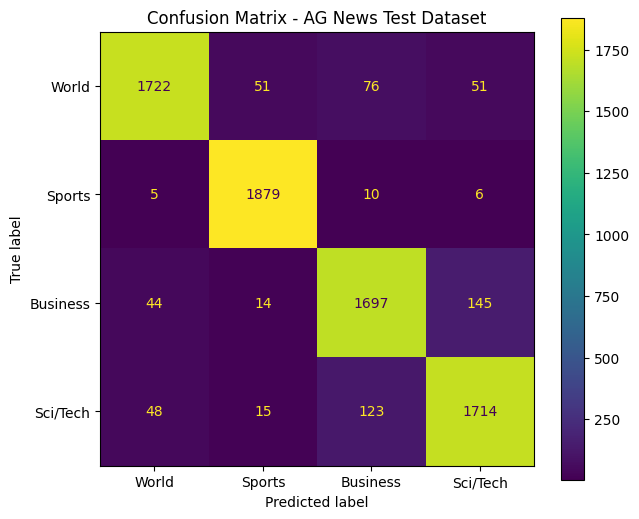

In [34]:
# Create and display the confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix - AG News Test Dataset")
plt.show()

### Interpretation of the Confusion Matrix

The confusion matrix shows that the model correctly classified 7,012 of the 7,600 test articles. Sports was the strongest-performing category, with 1,879 of 1,900 articles classified correctly. This is consistent with its high F1-score of 0.9738.

The largest source of confusion occurred between the Business and Sci/Tech categories. A total of 145 Business articles were classified as Sci/Tech, while 123 Sci/Tech articles were classified as Business. This overlap is reasonable because articles involving technology companies, investments, products, and markets may contain vocabulary associated with both topics.

The World category was also classified effectively, although 76 World articles were incorrectly predicted as Business. Overall, the concentration of values along the main diagonal demonstrates that the feed-forward neural network successfully learned meaningful topic-specific patterns from the bag-of-words features.